In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid')

print("Libraries loaded")

Libraries loaded


In [3]:
df = pd.read_csv('../data/loan.csv', 
                 low_memory=False, 
                 skiprows=lambda i: i > 0 and np.random.random() > 0.2)

print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Shape: (452437, 145)
Rows: 452,437
Columns: 145


In [4]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,...,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,6000,6000,6000.00,36 months,14.47,206.44,C,C2,NaN,< 1 year,OWN,300000.00,Not Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,068xx,CT,17.43,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,10000,10000,10000.00,36 months,13.56,339.65,C,C1,NaN,< 1 year,MORTGAGE,65000.00,Not Verified,Dec-2018,Current,n,NaN,NaN,credit_card,Credit card refinancing,937xx,CA,10.62,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,3500,3500,3500.00,36 months,20.89,131.67,D,D4,gas attendant,10+ years,MORTGAGE,40000.00,Source Verified,Dec-2018,Current,n,NaN,NaN,car,Car financing,078xx,NJ,9.09,...,0.00,46.00,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,15000,15000,14975.00,60 months,14.47,352.69,C,C2,NaN,NaN,MORTGAGE,30000.00,Source Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,756xx,TX,41.60,...,0.00,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,20000,20000,20000.00,60 months,11.80,442.88,B,B4,NaN,NaN,MORTGAGE,47590.00,Verified,Dec-2018,Current,n,NaN,NaN,credit_card,Credit card refinancing,156xx,PA,9.53,...,0.00,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DirectPay,N,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Drop anonymized ID columns
df = df.drop(columns=['id', 'member_id'])

print(f"Columns remaining: {df.shape[1]}")

Columns remaining: 143


In [6]:
# See all unique loan statuses
print(df['loan_status'].value_counts())

loan_status
Fully Paid                                             208507
Current                                                184392
Charged Off                                             52140
Late (31-120 days)                                       4321
In Grace Period                                          1783
Late (16-30 days)                                         715
Does not meet the credit policy. Status:Fully Paid        437
Does not meet the credit policy. Status:Charged Off       135
Default                                                     7
Name: count, dtype: int64


In [7]:
# Define default and non-default statuses
default_statuses = [
    'Charged Off',
    'Late (31-120 days)',
    'Late (16-30 days)',
    'Default',
    'Does not meet the credit policy. Status:Charged Off'
]

non_default_statuses = [
    'Fully Paid',
    'Does not meet the credit policy. Status:Fully Paid'
]

# Keep only resolved loans
df = df[df['loan_status'].isin(default_statuses + non_default_statuses)]

# Create binary target
df['is_default'] = df['loan_status'].isin(default_statuses).astype(int)

# Check class distribution
print(df['is_default'].value_counts())
print(f"\nDefault rate: {df['is_default'].mean():.2%}")
print(f"Rows remaining: {df.shape[0]:,}")

is_default
0    208944
1     57318
Name: count, dtype: int64

Default rate: 21.53%
Rows remaining: 266,262


C:\Users\aibha\AppData\Local\Temp\ipykernel_25320\3573038709.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['is_default'] = df['loan_status'].isin(default_statuses).astype(int)


In [8]:
df = df.copy()
print("Dataframe defragmented")
print(f"Shape: {df.shape}")

Dataframe defragmented
Shape: (266262, 144)


In [9]:
# Features known at origination only
cols_to_keep = [
    'loan_amnt',        # loan amount requested
    'term',             # 36 or 60 months
    'int_rate',         # interest rate
    'installment',      # monthly payment
    'grade',            # loan grade assigned by LC
    'sub_grade',        # sub grade
    'emp_length',       # employment length
    'home_ownership',   # rent/own/mortgage
    'annual_inc',       # annual income
    'verification_status',  # income verified?
    'purpose',          # loan purpose
    'dti',              # debt-to-income ratio
    'delinq_2yrs',      # delinquencies in past 2 years
    'open_acc',         # number of open credit lines
    'pub_rec',          # public derogatory records
    'revol_bal',        # revolving balance
    'revol_util',       # revolving utilization rate
    'total_acc',        # total credit lines
    'is_default'        # target variable
]

df = df[cols_to_keep]
print(f"Columns kept: {df.shape[1]}")
print(f"Shape: {df.shape}")

Columns kept: 19
Shape: (266262, 19)


In [10]:
# Check missing values
nulls = df.isnull().sum()
null_pct = (nulls / len(df) * 100).round(2)

null_summary = pd.DataFrame({
    'missing_count': nulls,
    'missing_pct': null_pct
}).sort_values('missing_pct', ascending=False)

print(null_summary[null_summary['missing_count'] > 0])

             missing_count  missing_pct
emp_length           15780         5.93
revol_util             157         0.06
dti                     67         0.03
open_acc                 7         0.00
delinq_2yrs              7         0.00
pub_rec                  7         0.00
total_acc                7         0.00


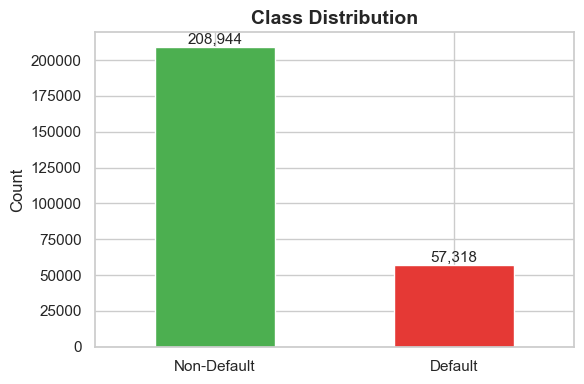

Plot saved 


In [13]:
fig, ax = plt.subplots(figsize=(6, 4))

colors = ['#4CAF50', '#E53935']
df['is_default'].value_counts().plot(kind='bar', ax=ax, color=colors, edgecolor='white')

ax.set_title('Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_xticklabels(['Non-Default', 'Default'], rotation=0)
ax.set_ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('../screenshots/class_distribution.png', dpi=150)
plt.show()
print("Plot saved ")

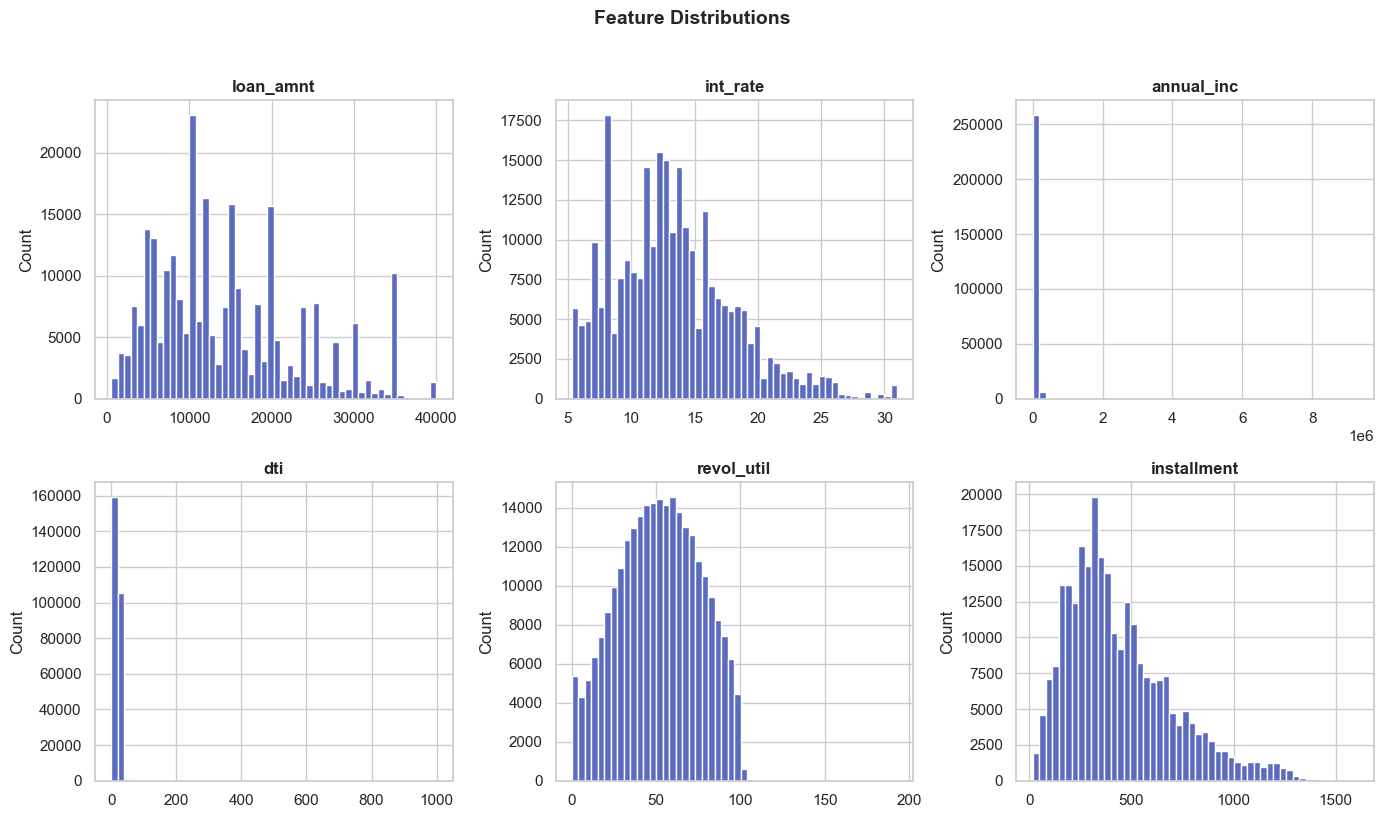

Plot saved 


In [14]:
numeric_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 
                'revol_util', 'installment']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=50, color='#5C6BC0', edgecolor='white')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../screenshots/feature_distributions.png', dpi=150)
plt.show()
print("Plot saved ")

In [15]:
# emp_length — categorical, fill with Unknown
df['emp_length'] = df['emp_length'].fillna('Unknown')

# Numeric columns — fill with median
median_cols = ['revol_util', 'dti', 'open_acc', 
               'delinq_2yrs', 'pub_rec', 'total_acc']

for col in median_cols:
    df[col] = df[col].fillna(df[col].median())

# Confirm no nulls remain
print(f"Remaining nulls: {df.isnull().sum().sum()}")

Remaining nulls: 0


In [16]:
# Strip whitespace from term and convert to numeric
df['term'] = df['term'].str.strip().str.replace(' months', '').astype(int)

# Strip % from revol_util if needed
df['revol_util'] = pd.to_numeric(df['revol_util'], errors='coerce')

# Standardize emp_length to ordered numeric
emp_map = {
    'Unknown': 0,
    '< 1 year': 0,
    '1 year': 1,
    '2 years': 2,
    '3 years': 3,
    '4 years': 4,
    '5 years': 5,
    '6 years': 6,
    '7 years': 7,
    '8 years': 8,
    '9 years': 9,
    '10+ years': 10
}

df['emp_length'] = df['emp_length'].map(emp_map)

print(df[['term', 'emp_length']].head())
print(f"\nNulls after cleaning: {df.isnull().sum().sum()}")

     term  emp_length
97     36          10
109    36           5
137    60          10
176    36           1
306    36           5

Nulls after cleaning: 0


In [17]:
# One-hot encode categorical columns
cat_cols = ['grade', 'sub_grade', 'home_ownership', 
            'verification_status', 'purpose']

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f"Shape after encoding: {df.shape}")
print(f"Columns: {df.shape[1]}")

Shape after encoding: (266262, 74)
Columns: 74


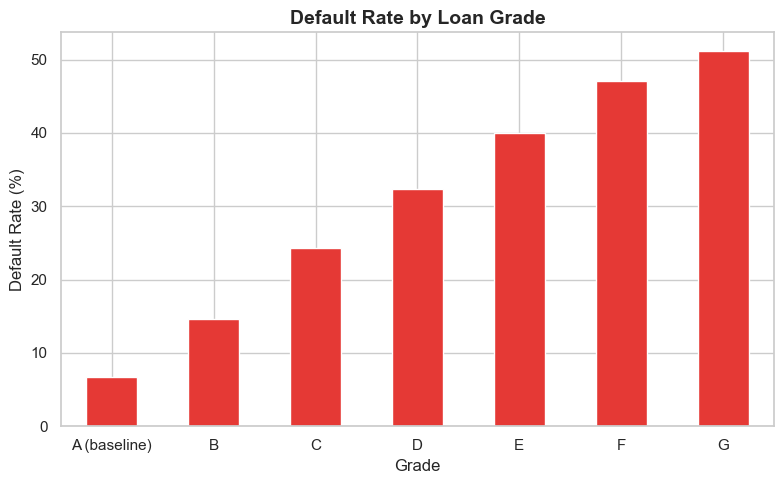

Plot saved


In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

grade_cols = [col for col in df.columns if col.startswith('grade_')]
grade_default = {}

for col in grade_cols:
    grade_name = col.replace('grade_', '')
    mask = df[col] == 1
    grade_default[grade_name] = df.loc[mask, 'is_default'].mean() * 100

# Add the baseline grade (dropped by get_dummies)
grade_default['A (baseline)'] = df[df[grade_cols].sum(axis=1) == 0]['is_default'].mean() * 100

grade_df = pd.Series(grade_default).sort_index()
grade_df.plot(kind='bar', ax=ax, color='#E53935', edgecolor='white')

ax.set_title('Default Rate by Loan Grade', fontsize=14, fontweight='bold')
ax.set_xlabel('Grade')
ax.set_ylabel('Default Rate (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('../screenshots/default_rate_by_grade.png', dpi=150)
plt.show()
print("Plot saved")

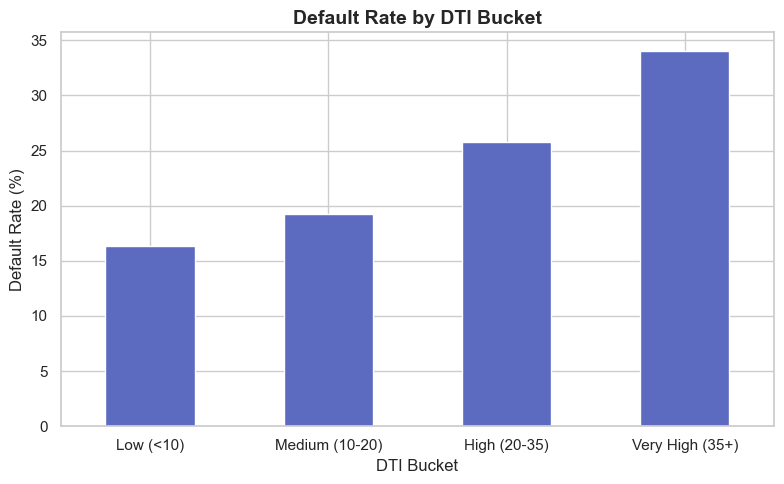

Plot saved 


In [20]:
fig, ax = plt.subplots(figsize=(8, 5))

df['dti_bucket'] = pd.cut(df['dti'],
                           bins=[0, 10, 20, 35, 100],
                           labels=['Low (<10)', 'Medium (10-20)', 
                                   'High (20-35)', 'Very High (35+)'])

dti_default = df.groupby('dti_bucket', observed=True)['is_default'].mean() * 100
dti_default.plot(kind='bar', ax=ax, color='#5C6BC0', edgecolor='white')

ax.set_title('Default Rate by DTI Bucket', fontsize=14, fontweight='bold')
ax.set_xlabel('DTI Bucket')
ax.set_ylabel('Default Rate (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('../screenshots/default_rate_by_dti.png', dpi=150)
plt.show()
print("Plot saved ")